# Precious Metals Portfolio — Value-at-Risk & Risk Management

**Portfolio:** $1,000,000 notional, equal-weight (1/3 each) in
Gold (`GC=F`), Silver (`SI=F`) and Platinum (`PL=F`) COMEX futures.

**Period:** 2019-01-01 → 2024-12-31.

This notebook builds a full market-risk workbench:

| Section | Content |
|---------|---------|
| 0 | Setup, data loading (live futures → ETF proxy), log returns |
| 1 | Descriptive stats, correlation (static + rolling), normality tests |
| 2 | VaR by three methods: Historical, Parametric, Monte Carlo |
| 3 | Expected Shortfall (CVaR) — the coherent tail measure |
| 4 | Backtesting the VaR model (Kupiec POF test) |
| 5 | Historical stress scenarios (COVID, Russia, flash crash, silver squeeze) |
| 6 | Rolling 252-day VaR (model stability through time) |
| 7 | Clean summary table |
| Export | `precious_metals_var_results.xlsx` + all figures @150 dpi |

**Reading guide for a precious-metals trader.** VaR answers *"how much can I
lose on a normal bad day?"*; ES answers *"and when that bad day actually
arrives, how bad does it get?"*. Precious metals have fat tails and
correlations that spike in crises (the diversification you paid for
evaporates exactly when you need it), so we deliberately compare a
distribution-free method (Historical) against a normal-distribution method
(Parametric) to *quantify* how much the normal assumption understates risk.


## Section 0 — Setup & Data Loading

**What it computes.** Downloads daily prices for the three metals and converts
them to daily **log returns** `r_t = ln(P_t / P_{t-1})`. Log returns are used
(not simple returns) because they are additive across time, symmetric, and the
natural input to the normal-distribution machinery in Section 2.

**What it means for a trader.** The descriptive stats printed here are the raw
risk DNA of each leg: annualized volatility tells you how jumpy the price is,
**skew** tells you whether crashes or melt-ups dominate, and **kurtosis > 3**
("fat tails") is the early warning that a normal-VaR model will lie to you.


In [21]:
# --- Core imports -------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2

try:
    import yfinance as yf
    HAVE_YF = True
except Exception as e:
    HAVE_YF = False
    print("yfinance not available:", e)

np.random.seed(42)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

START = "2019-01-01"
END   = "2024-12-31"

PORTFOLIO_VALUE = 1_000_000.0
WEIGHTS = np.array([1/3, 1/3, 1/3])
ASSETS  = ["Gold", "Silver", "Platinum"]

def money(x):
    """Format a number as $X,XXX (negatives in parentheses)."""
    x = float(x)
    if x < 0:
        return f"(${abs(x):,.0f})"
    return f"${x:,.0f}"

print("Setup complete. Portfolio value:", money(PORTFOLIO_VALUE))
print("Weights:", dict(zip(ASSETS, WEIGHTS.round(4))))


Setup complete. Portfolio value: $1,000,000
Weights: {'Gold': np.float64(0.3333), 'Silver': np.float64(0.3333), 'Platinum': np.float64(0.3333)}


In [22]:
# --- Data loaders: live futures -> ETF proxy ----------------------------
# Each asset tries its COMEX futures ticker first; if that fails it falls
# back to the liquid ETF proxy. (No synthetic fallback: this analysis runs
# on real market data only.)

FUTURES = {"Gold": "GC=F", "Silver": "SI=F", "Platinum": "PL=F"}
ETFS    = {"Gold": "GLD",  "Silver": "SLV",  "Platinum": "PPLT"}

def _try_download(ticker):
    """Return a clean price Series for one ticker, or None on failure."""
    if not HAVE_YF:
        return None
    try:
        df = yf.download(ticker, start=START, end=END,
                         progress=False, auto_adjust=True)
        if df is None or len(df) == 0:
            return None
        # Handle possible MultiIndex columns from yfinance
        if isinstance(df.columns, pd.MultiIndex):
            close = df["Close"]
            s = close.iloc[:, 0] if close.ndim > 1 else close
        else:
            s = df["Close"]
        s = s.dropna()
        if len(s) < 100:
            return None
        return s.astype(float)
    except Exception as e:
        print(f"   download failed for {ticker}: {e}")
        return None

prices = {}
source_tag = {}

for name in ASSETS:
    s = _try_download(FUTURES[name])
    tag = "live"
    if s is None:
        s = _try_download(ETFS[name])
        tag = "ETF"
    if s is None:
        raise RuntimeError(
            f"Could not download {name} from futures ({FUTURES[name]}) "
            f"or ETF proxy ({ETFS[name]}). Check network / yfinance.")
    prices[name] = s
    source_tag[name] = tag

# Print source tags
print("Data source per series:")
for a in ASSETS:
    print(f"   {a:<9} : {source_tag[a].upper():<10} ({len(prices[a])} obs)")


Data source per series:
   Gold      : LIVE       (1509 obs)
   Silver    : LIVE       (1509 obs)
   Platinum  : LIVE       (1509 obs)


In [23]:
# --- Align prices, compute log returns ----------------------------------
px = pd.DataFrame({a: prices[a] for a in ASSETS}).sort_index()
px = px.dropna(how="any")               # common trading days only
px.columns = ASSETS

returns = np.log(px / px.shift(1)).dropna()
returns.columns = ASSETS

print(f"Aligned sample: {px.index.min().date()} -> {px.index.max().date()}")
print(f"N price obs: {len(px)}  |  N return obs: {len(returns)}")
px.tail(3)


Aligned sample: 2019-01-02 -> 2024-12-30
N price obs: 1509  |  N return obs: 1508


,Gold,Silver,Platinum
Date,,,
2024-12-26,"2,639",30,952
2024-12-27,"2,617",30,918
2024-12-30,"2,606",29,902


In [24]:
# --- Per-asset descriptive statistics -----------------------------------
print("="*86)
print("PER-ASSET RETURN STATISTICS (daily log returns)")
print("="*86)
hdr = f"{'Asset':<9}{'N':>7}{'mean':>11}{'std':>10}{'ann.vol':>10}{'skew':>9}{'kurt':>9}"
print(hdr)
print("-"*86)
desc_rows = {}
for a in ASSETS:
    r = returns[a]
    mean = r.mean()
    std  = r.std()
    annv = std * np.sqrt(252)
    skew = stats.skew(r)
    kurt = stats.kurtosis(r, fisher=False)   # raw kurtosis (normal = 3)
    desc_rows[a] = [len(r), mean, std, annv, skew, kurt]
    print(f"{a:<9}{len(r):>7}{mean:>11.5f}{std:>10.4f}{annv:>9.1%}{skew:>9.2f}{kurt:>9.2f}")
print("-"*86)
print("Note: kurtosis is RAW (normal = 3.0). Values >> 3 mean fat tails ->")
print("      a normal-distribution VaR will UNDER-state true tail risk.")
desc_df = pd.DataFrame(desc_rows, index=["N","mean","std","ann_vol","skew","kurtosis"]).T


PER-ASSET RETURN STATISTICS (daily log returns)
Asset          N       mean       std   ann.vol     skew     kurt
--------------------------------------------------------------------------------------
Gold        1508    0.00047    0.0098    15.6%    -0.30     6.83
Silver      1508    0.00042    0.0202    32.0%    -0.42     7.66
Platinum    1508    0.00008    0.0194    30.9%    -0.22     6.10
--------------------------------------------------------------------------------------
Note: kurtosis is RAW (normal = 3.0). Values >> 3 mean fat tails ->
      a normal-distribution VaR will UNDER-state true tail risk.


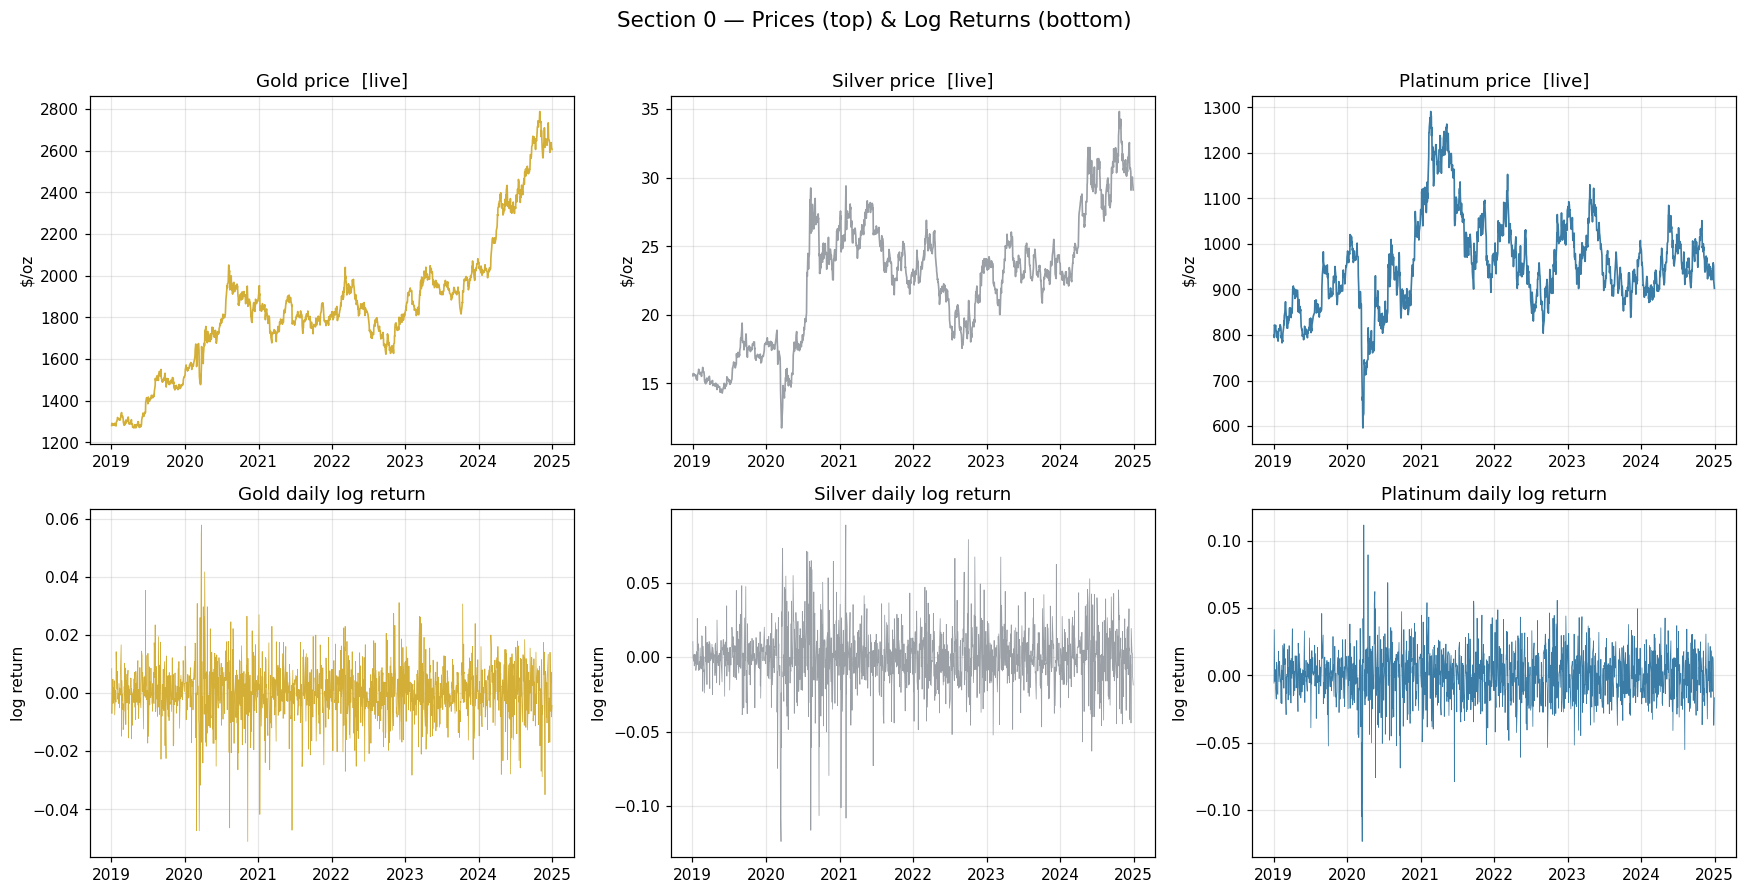

saved fig0_prices_returns.png


In [25]:
# --- Figure 0: price & return panels ------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
colors = {"Gold": "#D4AF37", "Silver": "#9AA0A6", "Platinum": "#3A7CA5"}
for j, a in enumerate(ASSETS):
    axes[0, j].plot(px.index, px[a], color=colors[a], lw=1.1)
    axes[0, j].set_title(f"{a} price  [{source_tag[a]}]")
    axes[0, j].set_ylabel("$/oz" if source_tag[a] != "ETF" else "ETF px")
    axes[1, j].plot(returns.index, returns[a], color=colors[a], lw=0.5)
    axes[1, j].set_title(f"{a} daily log return")
    axes[1, j].set_ylabel("log return")
fig.suptitle("Section 0 — Prices (top) & Log Returns (bottom)", fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig("fig0_prices_returns.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved fig0_prices_returns.png")


## Section 1 — Descriptive Statistics & Correlation

**What it computes.** (1a) the full-sample Pearson correlation matrix with
p-values; (1b) 90-day **rolling** correlations to show how co-movement breaks
down; (1c) per-asset return distributions vs a fitted normal, with a
Jarque-Bera normality test.

**What it means for a trader.** Diversification is only as good as the
correlation is low. The rolling panel is the punchline: in calm markets the
three metals drift apart, but in a crisis (COVID, the Russia invasion) they
lurch together — correlation goes to 1 precisely when you wanted it near 0.
The JB test formalises the fat-tail warning: if normality is rejected, trust
the Historical/ES numbers over the Parametric one.


In [26]:
# --- 1a. Full-sample correlation matrix with p-values -------------------
corr = returns.corr(method="pearson")

pvals = pd.DataFrame(np.ones((3, 3)), index=ASSETS, columns=ASSETS)
for i, a in enumerate(ASSETS):
    for j, b in enumerate(ASSETS):
        if i != j:
            _, p = stats.pearsonr(returns[a], returns[b])
            pvals.loc[a, b] = p

print("="*60)
print("PEARSON CORRELATION MATRIX (daily log returns, full sample)")
print("="*60)
print(corr.round(3).to_string())
print("\nP-VALUES (H0: correlation = 0):")
print(pvals.round(4).to_string())
print("\nAll off-diagonal correlations are positive and (typically)")
print("highly significant -> the legs share common precious-metal beta.")


PEARSON CORRELATION MATRIX (daily log returns, full sample)
          Gold  Silver  Platinum
Gold         1       1         1
Silver       1       1         1
Platinum     1       1         1

P-VALUES (H0: correlation = 0):
          Gold  Silver  Platinum
Gold         1       0         0
Silver       0       1         0
Platinum     0       0         1

All off-diagonal correlations are positive and (typically)
highly significant -> the legs share common precious-metal beta.


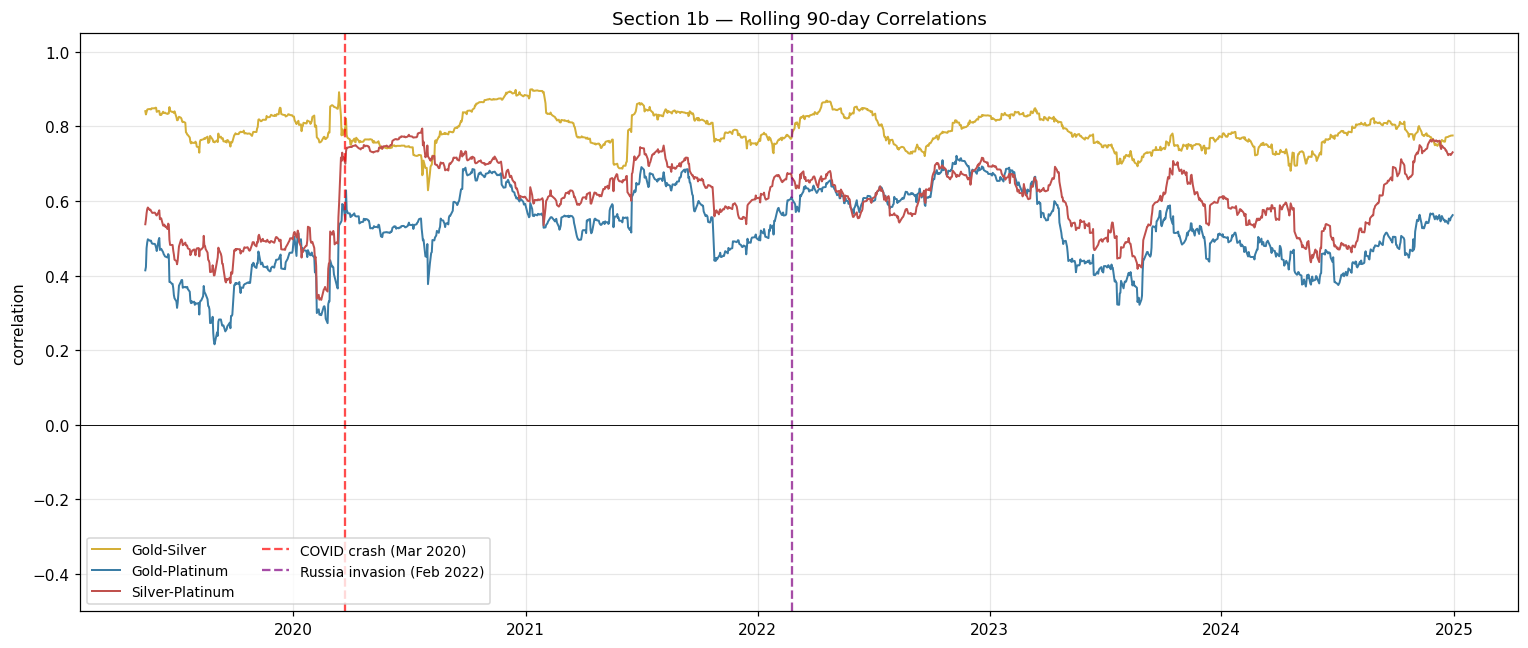

saved fig1_rolling_correlations.png
Observe correlation spikes around the marked crisis dates -> the
diversification benefit shrinks exactly when losses cluster.


In [27]:
# --- 1b. Rolling 90-day correlations ------------------------------------
roll = pd.DataFrame(index=returns.index)
roll["Gold-Silver"]     = returns["Gold"].rolling(90).corr(returns["Silver"])
roll["Gold-Platinum"]   = returns["Gold"].rolling(90).corr(returns["Platinum"])
roll["Silver-Platinum"] = returns["Silver"].rolling(90).corr(returns["Platinum"])

COVID  = pd.Timestamp("2020-03-23")
RUSSIA = pd.Timestamp("2022-02-24")

fig, ax = plt.subplots(figsize=(14, 6))
for col, c in zip(roll.columns, ["#D4AF37", "#3A7CA5", "#C0504D"]):
    ax.plot(roll.index, roll[col], label=col, lw=1.3, color=c)
ax.axvline(COVID,  color="red",   ls="--", alpha=0.7, label="COVID crash (Mar 2020)")
ax.axvline(RUSSIA, color="purple",ls="--", alpha=0.7, label="Russia invasion (Feb 2022)")
ax.axhline(0, color="black", lw=0.6)
ax.set_title("Section 1b — Rolling 90-day Correlations")
ax.set_ylabel("correlation"); ax.set_ylim(-0.5, 1.05)
ax.legend(loc="lower left", ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig("fig1_rolling_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved fig1_rolling_correlations.png")
print("Observe correlation spikes around the marked crisis dates -> the")
print("diversification benefit shrinks exactly when losses cluster.")


JARQUE-BERA NORMALITY TEST (H0: returns are normal)
Gold      JB=     943.0  p=1.73e-205  kurt= 6.83 (FAT-TAILED) -> REJECT normal
Silver    JB=    1410.0  p=6.67e-307  kurt= 7.66 (FAT-TAILED) -> REJECT normal
Platinum  JB=     614.8  p=3.08e-134  kurt= 6.10 (FAT-TAILED) -> REJECT normal


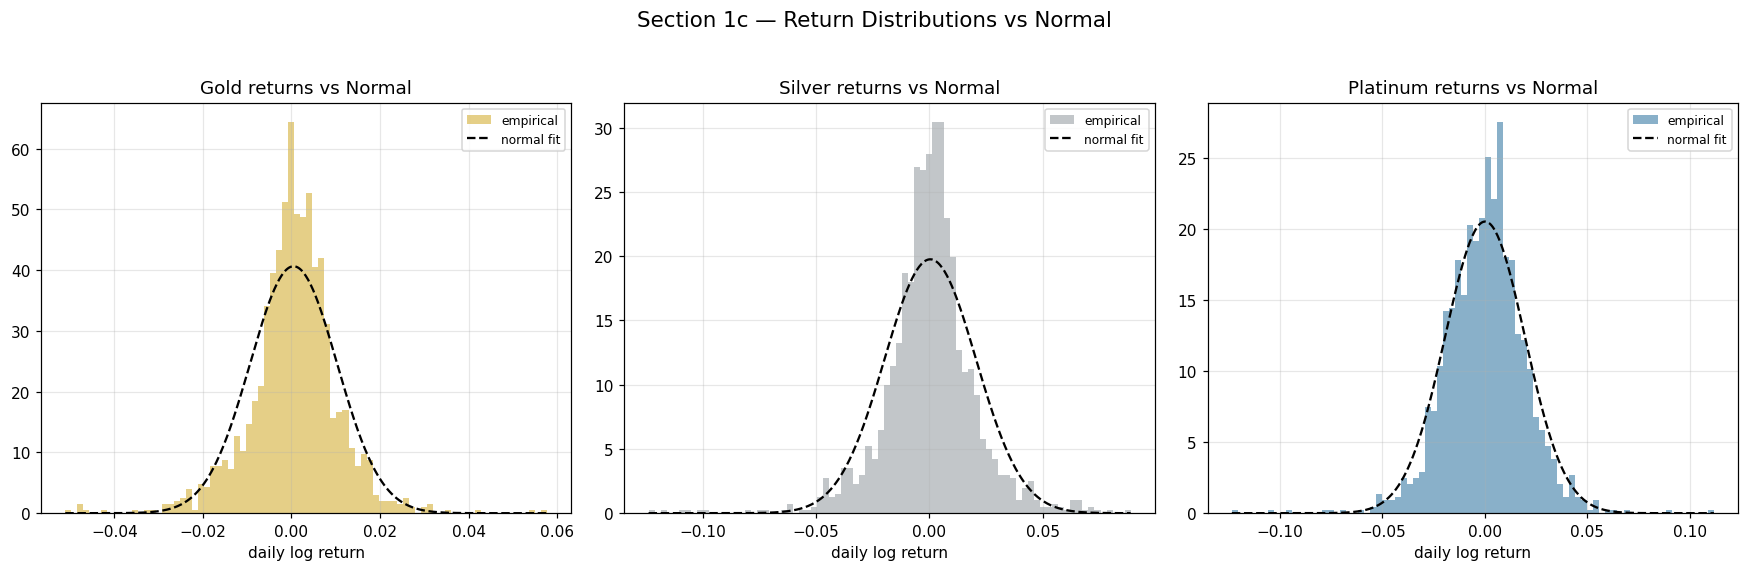


Fat tails + JB rejection => the Parametric (normal) VaR in Section 2
will systematically UNDER-estimate the 99% loss. We quantify this next.


In [28]:
# --- 1c. Distribution analysis + Jarque-Bera ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
print("="*60)
print("JARQUE-BERA NORMALITY TEST (H0: returns are normal)")
print("="*60)
jb_rows = {}
for j, a in enumerate(ASSETS):
    r = returns[a]
    jb_stat, jb_p = stats.jarque_bera(r)
    kurt = stats.kurtosis(r, fisher=False)
    fat = "FAT-TAILED" if kurt > 3 else "thin-tailed"
    verdict = "REJECT normal" if jb_p < 0.05 else "cannot reject"
    jb_rows[a] = [jb_stat, jb_p, kurt, fat, verdict]
    print(f"{a:<9} JB={jb_stat:>10.1f}  p={jb_p:.2e}  kurt={kurt:5.2f} "
          f"({fat}) -> {verdict}")

    ax = axes[j]
    ax.hist(r, bins=80, density=True, alpha=0.6, color=colors[a], label="empirical")
    xs = np.linspace(r.min(), r.max(), 400)
    ax.plot(xs, stats.norm.pdf(xs, r.mean(), r.std()),
            "k--", lw=1.5, label="normal fit")
    ax.set_title(f"{a} returns vs Normal")
    ax.set_xlabel("daily log return"); ax.legend(fontsize=8)
fig.suptitle("Section 1c — Return Distributions vs Normal", fontsize=14, y=1.03)
fig.tight_layout()
fig.savefig("fig1c_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nFat tails + JB rejection => the Parametric (normal) VaR in Section 2")
print("will systematically UNDER-estimate the 99% loss. We quantify this next.")
jb_df = pd.DataFrame(jb_rows, index=["JB_stat","p_value","kurtosis","tails","verdict"]).T


## Section 2 — Value at Risk (three methods)

**What it computes.** 1-day and 10-day VaR at 95% and 99% for each metal
standalone **and** for the equal-weight portfolio, using three methods:

1. **Historical Simulation** — empirical percentile of past P&L. No
   distribution assumption; keeps the real fat tails and crisis days.
2. **Parametric (variance-covariance)** — assumes normal returns,
   `VaR = (-μ + z·σ)·V`. Fast, but blind to fat tails.
3. **Monte Carlo** — 10,000 correlated draws from the empirical mean vector
   and covariance matrix (Cholesky), then read the percentile.

The 10-day figure uses the square-root-of-time rule (`×√10`).

**What it means for a trader.** Three lenses on the same risk. Where Historical
> Parametric, the gap is the *fat-tail tax* the normal model ignores. Where the
portfolio VaR is below the sum of the standalone VaRs, that gap is your
**diversification benefit** — real, but fragile (see the rolling correlations).


In [29]:
# --- VaR engine ---------------------------------------------------------
Z = {0.95: 1.645, 0.99: 2.326}     # one-sided normal quantiles
SQRT10 = np.sqrt(10)

def var_historical(ret_series, conf, value):
    """Historical-simulation VaR ($, positive = loss) for a return series."""
    pnl = ret_series.values * value
    pct = (1 - conf) * 100            # 95% -> 5th pctile, 99% -> 1st
    return -np.percentile(pnl, pct)

def var_parametric(ret_series, conf, value):
    """Variance-covariance VaR assuming normality."""
    mu, sig = ret_series.mean(), ret_series.std()
    return (-mu + Z[conf] * sig) * value

def var_montecarlo(mu_vec, cov_mat, w, conf, value, n_sims=10_000):
    """Monte-Carlo VaR via Cholesky-correlated normal draws."""
    L = np.linalg.cholesky(cov_mat)
    Zmat = np.random.standard_normal((n_sims, len(w)))
    sim_r = mu_vec + Zmat @ L.T
    sim_pnl = (sim_r @ w) * value
    return -np.percentile(sim_pnl, (1 - conf) * 100), sim_pnl

# Portfolio return series
portfolio_returns = returns @ WEIGHTS
portfolio_pnl     = portfolio_returns * PORTFOLIO_VALUE

mu_vec  = returns.mean().values
cov_mat = returns.cov().values

print("VaR engine ready. Portfolio daily P&L stats:")
print(f"   mean = {money(portfolio_pnl.mean())}   std = {money(portfolio_pnl.std())}")


VaR engine ready. Portfolio daily P&L stats:
   mean = $323   std = $14,493


In [30]:
# --- Compute VaR for every asset + portfolio, all methods ---------------
# Convention: each STANDALONE asset is risked at the full $1M notional so the
# numbers are directly comparable; the portfolio is the 1/3-1/3-1/3 blend.
rows = []
# individual assets
for a in ASSETS:
    r = returns[a]
    for conf in (0.95, 0.99):
        hs = var_historical(r, conf, PORTFOLIO_VALUE)
        pm = var_parametric(r, conf, PORTFOLIO_VALUE)
        # single-asset MC: 1x1 covariance
        mc, _ = var_montecarlo(np.array([r.mean()]), np.array([[r.var()]]),
                               np.array([1.0]), conf, PORTFOLIO_VALUE)
        rows.append([a, conf, hs, hs*SQRT10, pm, pm*SQRT10, mc, mc*SQRT10])

# portfolio
for conf in (0.95, 0.99):
    hs = var_historical(portfolio_returns, conf, PORTFOLIO_VALUE)
    pm = var_parametric(portfolio_returns, conf, PORTFOLIO_VALUE)
    mc, sim_pnl_store = var_montecarlo(mu_vec, cov_mat, WEIGHTS, conf, PORTFOLIO_VALUE)
    rows.append(["Portfolio", conf, hs, hs*SQRT10, pm, pm*SQRT10, mc, mc*SQRT10])

var_df = pd.DataFrame(rows, columns=[
    "Asset","Conf","HS_1d","HS_10d","Param_1d","Param_10d","MC_1d","MC_10d"])

# Keep the 99% portfolio Monte-Carlo P&L vector for Sections 3
_, sim_pnl = var_montecarlo(mu_vec, cov_mat, WEIGHTS, 0.99, PORTFOLIO_VALUE)

pd.set_option("display.float_format", lambda v: f"{v:,.0f}")
print("Full VaR table ($, positive = loss):")
print(var_df.to_string(index=False))


Full VaR table ($, positive = loss):
    Asset  Conf  HS_1d  HS_10d  Param_1d  Param_10d  MC_1d  MC_10d
     Gold     1 16,348  51,696    15,682     49,592 15,779  49,898
     Gold     1 26,438  83,606    22,369     70,738 22,876  72,341
   Silver     1 32,627 103,174    32,790    103,693 32,225 101,904
   Silver     1 51,839 163,931    46,537    147,164 47,116 148,994
 Platinum     1 28,915  91,439    31,898    100,872 32,071 101,418
 Platinum     1 49,729 157,255    45,137    142,736 46,343 146,550
Portfolio     1 22,962  72,611    23,518     74,371 23,017  72,786
Portfolio     1 37,985 120,121    33,388    105,582 33,471 105,844


In [31]:
# --- Headline comparison table (portfolio) ------------------------------
pf = var_df[var_df.Asset == "Portfolio"].set_index("Conf")
hs95, hs99 = pf.loc[0.95,"HS_1d"],   pf.loc[0.99,"HS_1d"]
pm95, pm99 = pf.loc[0.95,"Param_1d"],pf.loc[0.99,"Param_1d"]
mc95, mc99 = pf.loc[0.95,"MC_1d"],   pf.loc[0.99,"MC_1d"]
hs99_10    = pf.loc[0.99,"HS_10d"]
pm99_10    = pf.loc[0.99,"Param_10d"]
mc99_10    = pf.loc[0.99,"MC_10d"]

print("="*74)
print("PORTFOLIO VaR — METHOD COMPARISON  ($1,000,000 equal-weight)")
print("="*74)
print(f"{'Method':<14}{'VaR 95% (1d)':>16}{'VaR 99% (1d)':>16}{'VaR 99% (10d)':>16}")
print("-"*74)
print(f"{'Historical':<14}{money(hs95):>16}{money(hs99):>16}{money(hs99_10):>16}")
print(f"{'Parametric':<14}{money(pm95):>16}{money(pm99):>16}{money(pm99_10):>16}")
print(f"{'Monte Carlo':<14}{money(mc95):>16}{money(mc99):>16}{money(mc99_10):>16}")
print("-"*74)
bias = (pm99 - hs99) / hs99 * 100
print(f"Parametric vs Historical (99% 1d): {bias:+.1f}%  "
      f"({'under' if bias < 0 else 'over'}-estimates tail risk)")

# diversification benefit check
sum_ind = var_df[(var_df.Asset!='Portfolio') & (var_df.Conf==0.99)]['HS_1d'].sum()
print(f"\nSum of standalone 99% VaRs: {money(sum_ind)}")
print(f"Portfolio 99% VaR:          {money(hs99)}")
print(f"Diversification benefit:    {money(sum_ind - hs99)} "
      f"({(1-hs99/sum_ind)*100:.1f}% reduction)")


PORTFOLIO VaR — METHOD COMPARISON  ($1,000,000 equal-weight)
Method            VaR 95% (1d)    VaR 99% (1d)   VaR 99% (10d)
--------------------------------------------------------------------------
Historical             $22,962         $37,985        $120,121
Parametric             $23,518         $33,388        $105,582
Monte Carlo            $23,017         $33,471        $105,844
--------------------------------------------------------------------------
Parametric vs Historical (99% 1d): -12.1%  (under-estimates tail risk)

Sum of standalone 99% VaRs: $128,006
Portfolio 99% VaR:          $37,985
Diversification benefit:    $90,021 (70.3% reduction)


## Section 3 — Expected Shortfall (CVaR)

**What it computes.** ES is the *average* loss conditional on being beyond VaR:
`ES_99 = mean(losses worse than VaR_99)`. We compute it from the historical P&L
and from the Monte-Carlo P&L, plus the **ES/VaR ratio**.

**What it means for a trader.** VaR is a threshold — it tells you the door you
won't cross 99% of the time but says nothing about the room behind it. ES tells
you how deep that room is. It is a *coherent* risk measure (it rewards
diversification and never punishes it, unlike VaR), which is why Basel FRTB
replaced VaR with ES 97.5%. An ES/VaR ratio well above 1 means the tail is
long: when you lose, you tend to lose a lot more than the VaR line suggests.


In [32]:
# --- Expected Shortfall (historical + Monte Carlo) ----------------------
var_hs_99 = var_historical(portfolio_returns, 0.99, PORTFOLIO_VALUE)
var_hs_95 = var_historical(portfolio_returns, 0.95, PORTFOLIO_VALUE)

tail_hist = portfolio_pnl[portfolio_pnl < -var_hs_99]
ES_hist_99 = -tail_hist.mean()

tail_sim = sim_pnl[sim_pnl < -mc99]
ES_mc_99 = -tail_sim.mean()

es_ratio = ES_hist_99 / var_hs_99

print("="*64)
print("EXPECTED SHORTFALL — Portfolio, 99% confidence, 1-day")
print("="*64)
print(f"VaR 99% (1d)  : {money(var_hs_99):>12}  "
      f"-- on a bad day (1 in 100), lose at least this")
print(f"ES  99% (1d)  : {money(ES_hist_99):>12}  "
      f"-- when that bad day hits, lose this on average")
print(f"ES/VaR ratio  : {es_ratio:>12.2f}  -- tail-risk amplifier")
print(f"\n(Monte-Carlo ES 99%: {money(ES_mc_99)} — normal draws give a thinner")
print(" tail than history, so MC-ES typically sits below historical-ES.)")


EXPECTED SHORTFALL — Portfolio, 99% confidence, 1-day
VaR 99% (1d)  :      $37,985  -- on a bad day (1 in 100), lose at least this
ES  99% (1d)  :      $57,162  -- when that bad day hits, lose this on average
ES/VaR ratio  :         1.50  -- tail-risk amplifier

(Monte-Carlo ES 99%: $38,161 — normal draws give a thinner
 tail than history, so MC-ES typically sits below historical-ES.)


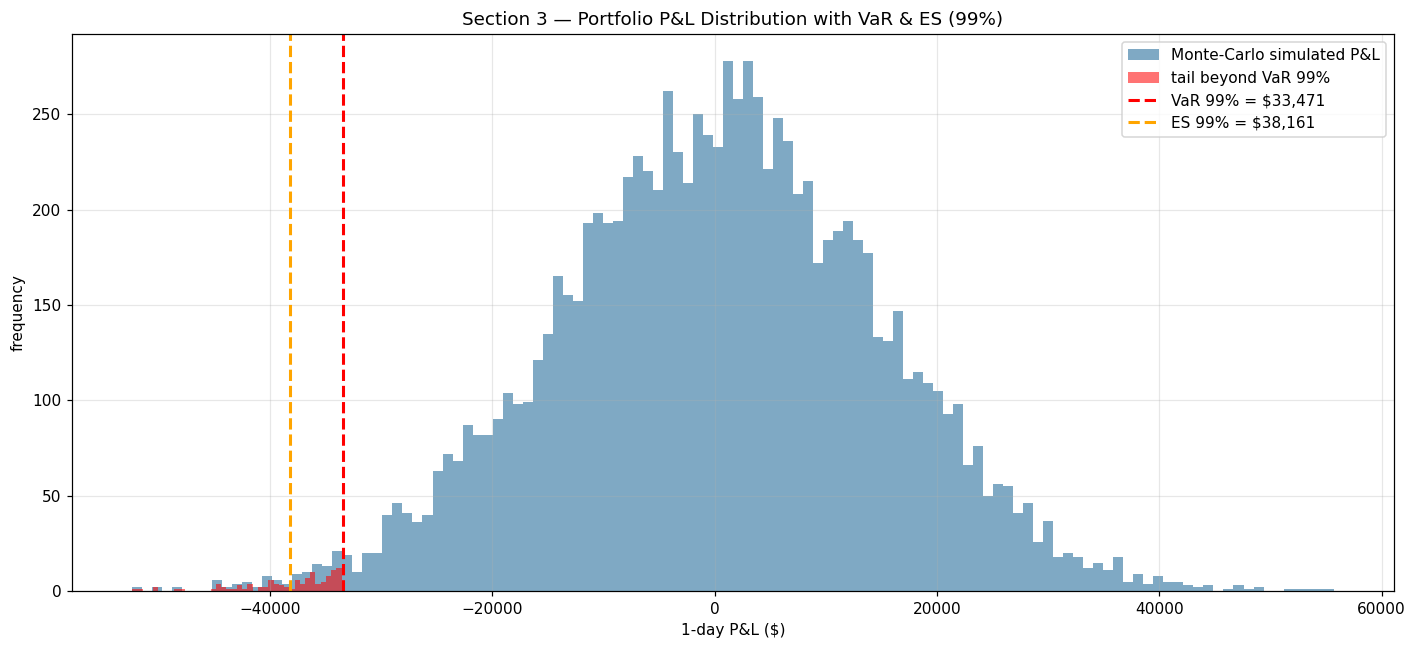

saved fig3_var_es_distribution.png


In [33]:
# --- Figure 3: P&L distribution with VaR & ES marked --------------------
fig, ax = plt.subplots(figsize=(13, 6))
ax.hist(sim_pnl, bins=120, color="#3A7CA5", alpha=0.65,
        label="Monte-Carlo simulated P&L")

# shade tail beyond VaR
tail_mask = sim_pnl < -mc99
ax.hist(sim_pnl[tail_mask], bins=40, color="red", alpha=0.55,
        label="tail beyond VaR 99%")

ax.axvline(-mc99, color="red", ls="--", lw=2,
           label=f"VaR 99% = {money(mc99)}")
ax.axvline(-ES_mc_99, color="orange", ls="--", lw=2,
           label=f"ES 99% = {money(ES_mc_99)}")
ax.set_title("Section 3 — Portfolio P&L Distribution with VaR & ES (99%)")
ax.set_xlabel("1-day P&L ($)"); ax.set_ylabel("frequency")
ax.legend()
fig.tight_layout()
fig.savefig("fig3_var_es_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved fig3_var_es_distribution.png")


## Section 4 — Backtesting (Kupiec POF test)

**What it computes.** A 99% VaR should be breached on ~1% of days. We count the
historical breaches, compare to the 1% expectation, and run the **Kupiec
Proportion-of-Failures** likelihood-ratio test (`LR ~ χ²(1)` under H0: true
breach rate = 1%).

**What it means for a trader.** This is the model's report card. Too many
breaches → the model is dangerously optimistic and you are under-reserved
(regulators will add a capital multiplier). Too few → you are over-reserved and
leaving return on the table. Note the breaches cluster in the crisis windows —
a known weakness of unconditional VaR that motivates conditional/EWMA models.


In [34]:
# --- 4a + 4b. Violation count and Kupiec POF test -----------------------
violations_mask = portfolio_pnl < -var_hs_99
violations = int(violations_mask.sum())
T = len(portfolio_pnl)
expected = T * 0.01
actual_pct = violations / T * 100

print("="*60)
print("BACKTESTING — Historical VaR 99% (1-day)")
print("="*60)
print(f"Observed violations: {violations} ({actual_pct:.2f}% of days)")
print(f"Expected violations: {expected:.1f} (1.00% of days)")

p_hat = violations / T
p0 = 0.01
# Guard against p_hat = 0 (log blows up)
if p_hat == 0:
    LR = -2 * (T * np.log(1 - p0))
else:
    LR = -2 * (violations * np.log(p0 / p_hat) +
               (T - violations) * np.log((1 - p0) / (1 - p_hat)))
p_value = 1 - chi2.cdf(LR, df=1)
conclusion = "ACCEPTED" if p_value > 0.05 else "REJECTED"

print(f"\nKupiec LR statistic: {LR:.3f}")
print(f"p-value            : {p_value:.3f}")
print(f"Conclusion         : Model {conclusion} at the 5% level")
print("   (p>0.05 => observed breach rate is statistically consistent with 1%)")


BACKTESTING — Historical VaR 99% (1-day)
Observed violations: 16 (1.06% of days)
Expected violations: 15.1 (1.00% of days)

Kupiec LR statistic: 0.056
p-value            : 0.814
Conclusion         : Model ACCEPTED at the 5% level
   (p>0.05 => observed breach rate is statistically consistent with 1%)


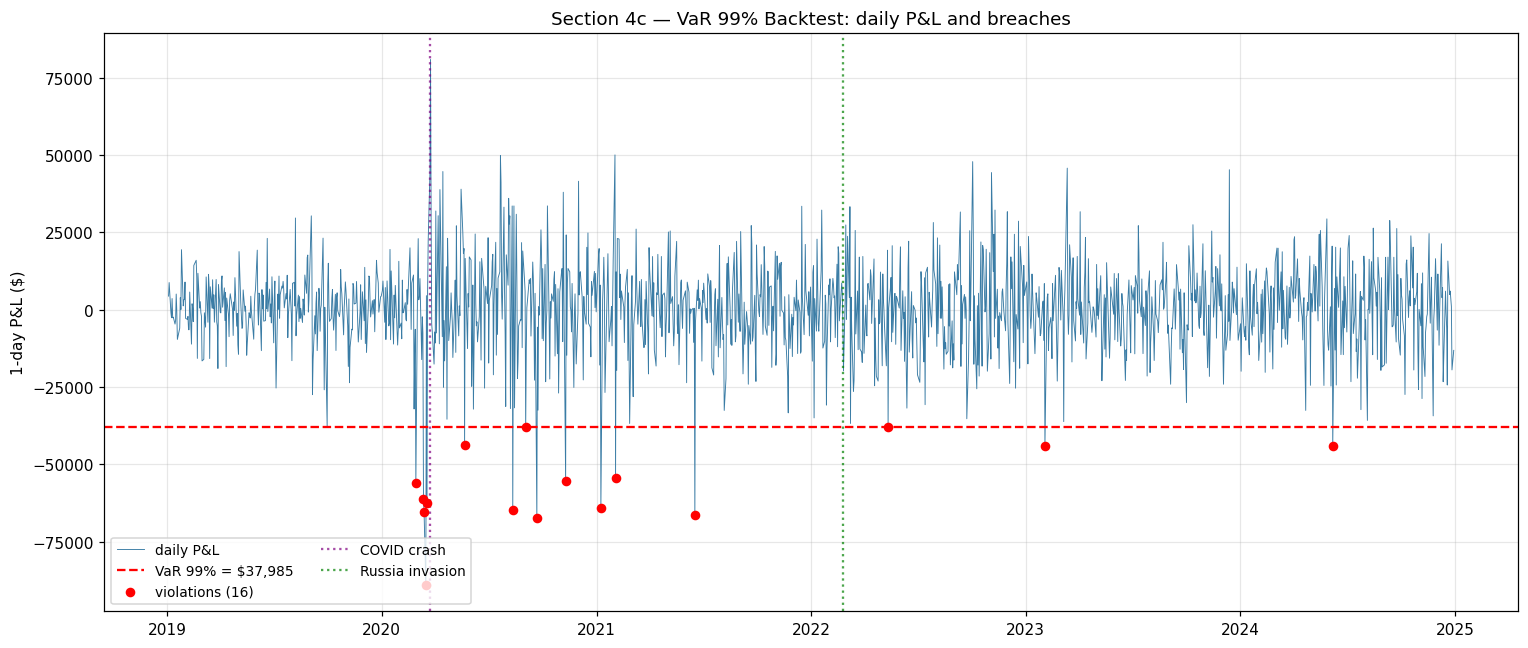

saved fig4_var_backtesting.png


In [35]:
# --- 4c. Plot violations over time --------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(portfolio_pnl.index, portfolio_pnl.values, color="#3A7CA5",
        lw=0.6, label="daily P&L")
ax.axhline(-var_hs_99, color="red", ls="--", lw=1.5,
           label=f"VaR 99% = {money(var_hs_99)}")
vdates = portfolio_pnl.index[violations_mask]
ax.scatter(vdates, portfolio_pnl[violations_mask], color="red", s=28,
           zorder=5, label=f"violations ({violations})")
ax.axvline(COVID,  color="purple", ls=":", alpha=0.7, label="COVID crash")
ax.axvline(RUSSIA, color="green",  ls=":", alpha=0.7, label="Russia invasion")
ax.set_title("Section 4c — VaR 99% Backtest: daily P&L and breaches")
ax.set_ylabel("1-day P&L ($)"); ax.legend(loc="lower left", ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig("fig4_var_backtesting.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved fig4_var_backtesting.png")

# store backtest results for export
bt_df = pd.DataFrame({
    "violation_date": vdates,
    "pnl": portfolio_pnl[violations_mask].values,
    "var_threshold": -var_hs_99,
})


## Section 5 — Scenario Analysis (historical stress testing)

**What it computes.** Replays four real episodes through the *current*
portfolio: COVID crash (Feb 20–Mar 23 2020), Russia invasion (Feb 24–Mar 15
2022), the Aug 9 2021 gold flash crash, and the Jan 2021 Reddit silver squeeze.
For each we report total P&L, worst day, and the per-leg returns.

**What it means for a trader.** VaR is calibrated to "normal" history; stress
tests ask "what if *that* happens again?". The Russia case is the instructive
one — gold's safe-haven bid can turn the metals book into a *hedge* that gains
when equities bleed. The silver squeeze shows idiosyncratic, single-leg tail
risk that a portfolio-level VaR can mask.


In [36]:
# --- Stress scenario engine ---------------------------------------------
def scenario_window(start, end, label):
    """Slice returns in [start, end], return P&L + per-leg cumulative ret."""
    sl = returns.loc[start:end]
    if len(sl) == 0:
        return None
    pnl_series = (sl @ WEIGHTS) * PORTFOLIO_VALUE
    leg_ret = (np.exp(sl.sum()) - 1)        # cumulative simple return per leg
    return {
        "label": label,
        "start": sl.index.min().date(),
        "end": sl.index.max().date(),
        "days": len(sl),
        "total_pnl": pnl_series.sum(),
        "worst_day": pnl_series.min(),
        "Gold": leg_ret["Gold"],
        "Silver": leg_ret["Silver"],
        "Platinum": leg_ret["Platinum"],
    }

scen_specs = [
    ("2020-02-20", "2020-03-23", "COVID crash"),
    ("2022-02-24", "2022-03-15", "Russia invasion"),
    ("2021-08-06", "2021-08-09", "Gold flash crash"),
    ("2021-01-27", "2021-02-02", "Silver squeeze"),
]

scen_results = [s for s in (scenario_window(*spec) for spec in scen_specs) if s]
scen_df = pd.DataFrame(scen_results)

print("="*92)
print("HISTORICAL STRESS SCENARIOS  ($1M equal-weight portfolio)")
print("="*92)
print(f"{'Scenario':<18}{'Period':<24}{'Days':>5}{'Portf P&L':>14}"
      f"{'Gold':>9}{'Silver':>9}{'Plat':>9}")
print("-"*92)
for s in scen_results:
    period = f"{s['start']}->{s['end']}"
    print(f"{s['label']:<18}{period:<24}{s['days']:>5}{money(s['total_pnl']):>14}"
          f"{s['Gold']:>9.1%}{s['Silver']:>9.1%}{s['Platinum']:>9.1%}")
print("-"*92)
print("Note: if Russia-invasion P&L is positive, gold's safe-haven rally")
print("turned the book into a hedge -- a gain, not a loss.")


HISTORICAL STRESS SCENARIOS  ($1M equal-weight portfolio)
Scenario          Period                   Days     Portf P&L     Gold   Silver     Plat
--------------------------------------------------------------------------------------------
COVID crash       2020-02-20->2020-03-23     23    ($272,527)    -2.5%   -27.7%   -37.4%
Russia invasion   2022-02-24->2022-03-15     14     ($17,182)     1.0%     2.3%    -8.1%
Gold flash crash  2021-08-06->2021-08-09      2     ($54,903)    -4.5%    -8.0%    -3.4%
Silver squeeze    2021-01-27->2021-02-02      5        $3,954    -1.1%     3.3%    -1.0%
--------------------------------------------------------------------------------------------
Note: if Russia-invasion P&L is positive, gold's safe-haven rally
turned the book into a hedge -- a gain, not a loss.


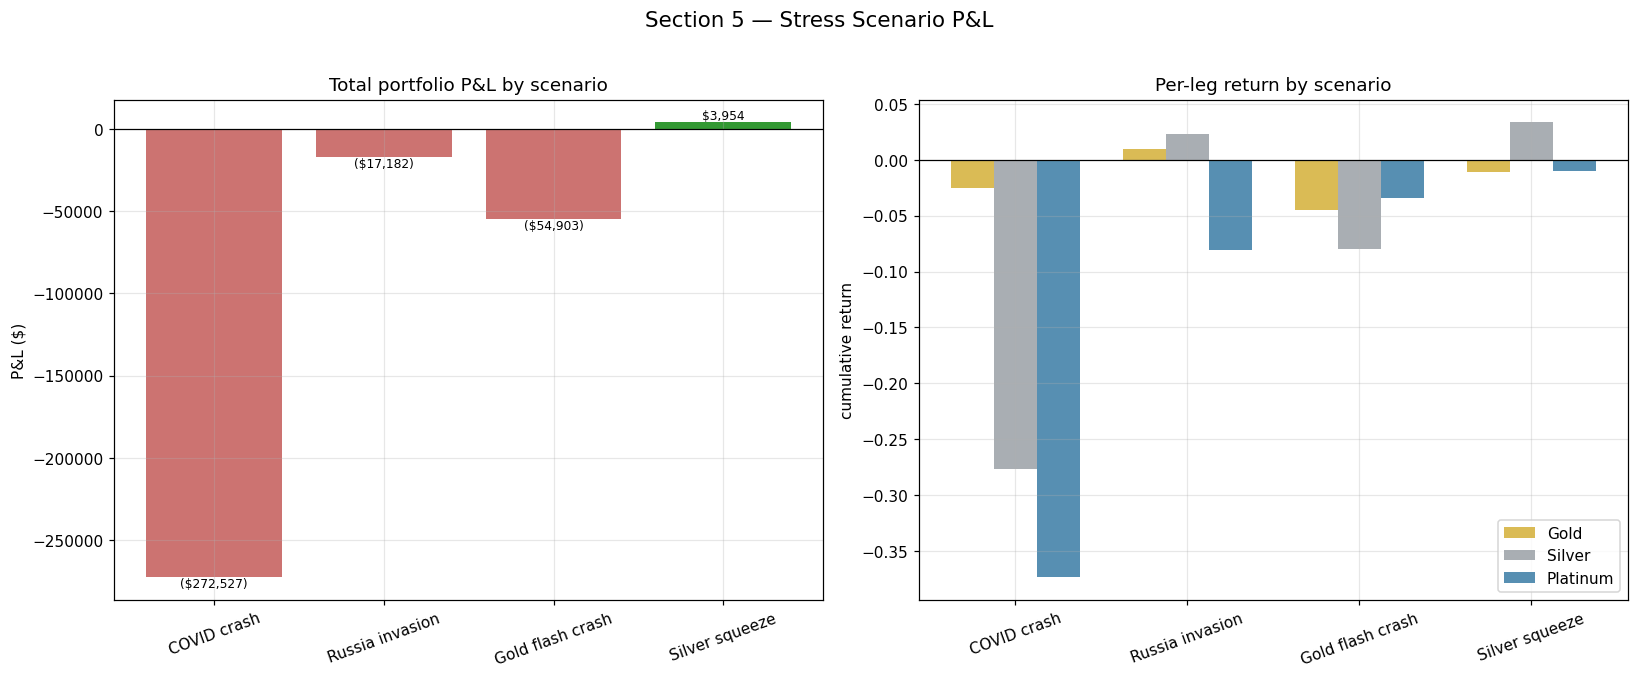

saved fig5_stress_scenarios.png


In [37]:
# --- Figure 5: 4-panel scenario P&L bar chart ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# left: total portfolio P&L per scenario
labels = [s["label"] for s in scen_results]
totals = [s["total_pnl"] for s in scen_results]
bar_colors = ["green" if v >= 0 else "#C0504D" for v in totals]
axes[0].bar(labels, totals, color=bar_colors, alpha=0.8)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Total portfolio P&L by scenario")
axes[0].set_ylabel("P&L ($)")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(totals):
    axes[0].text(i, v, money(v), ha="center",
                 va="bottom" if v >= 0 else "top", fontsize=8)

# right: per-leg returns grouped per scenario
x = np.arange(len(scen_results)); wdt = 0.25
for k, (a, c) in enumerate(zip(ASSETS, ["#D4AF37","#9AA0A6","#3A7CA5"])):
    vals = [s[a] for s in scen_results]
    axes[1].bar(x + (k-1)*wdt, vals, wdt, label=a, color=c, alpha=0.85)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=20)
axes[1].set_title("Per-leg return by scenario"); axes[1].set_ylabel("cumulative return")
axes[1].legend()
fig.suptitle("Section 5 — Stress Scenario P&L", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig("fig5_stress_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved fig5_stress_scenarios.png")


## Section 6 — Rolling VaR (model stability)

**What it computes.** A 252-day (≈1 trading year) rolling-window Historical VaR
99%, recomputed each day. This shows how the risk estimate itself breathes
through time.

**What it means for a trader.** A single full-sample VaR hides regime changes.
The rolling line reveals risk *ramping up* as a crisis enters the window and
*staying elevated* for a year afterwards (the window memory), then decaying as
the crisis day rolls out. It is the difference between a static speed limit and
a live speedometer — and it tells you when to resize the book.


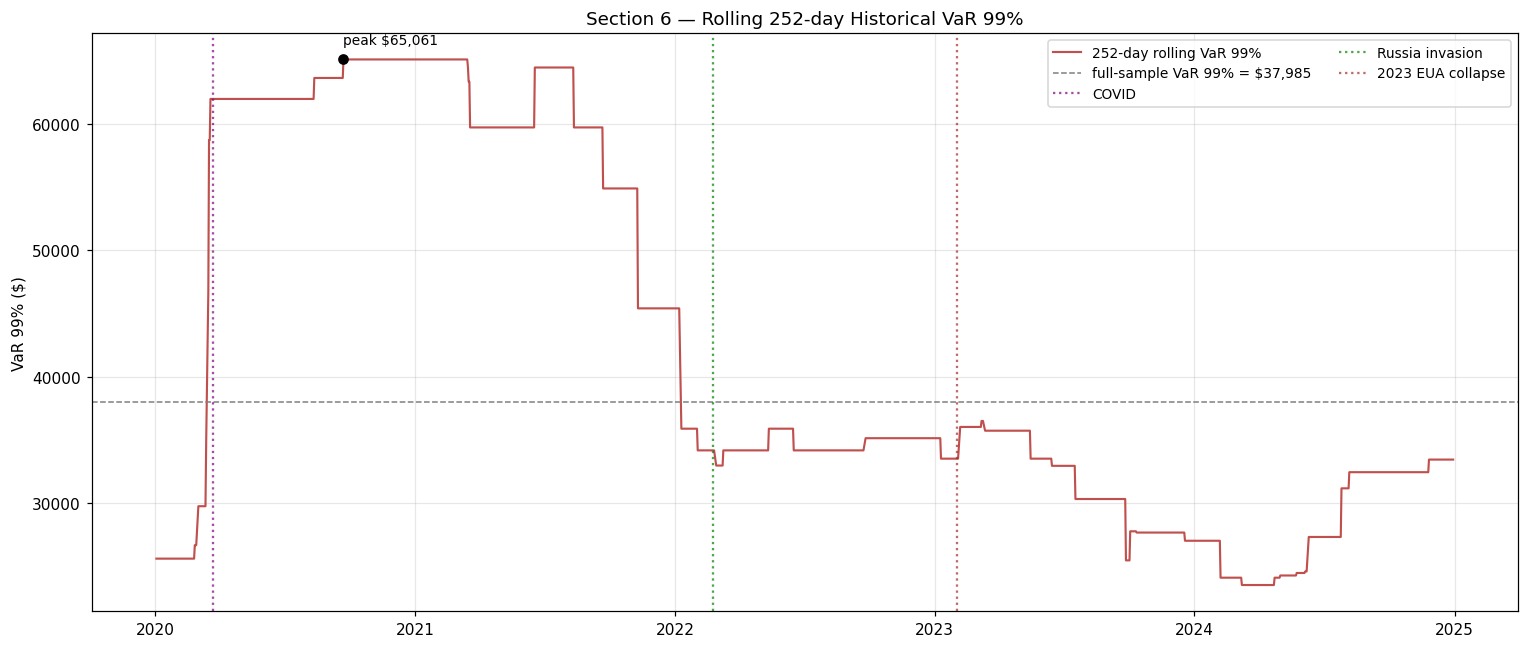

saved fig6_rolling_var.png
Peak risk : 2020-09-22  $65,061
Trough    : 2024-03-08  $23,549


In [38]:
# --- Rolling 252-day Historical VaR 99% ---------------------------------
WIN = 252
roll_idx, roll_var = [], []
pnl_vals = portfolio_pnl.values
for t in range(WIN, len(portfolio_pnl)):
    window = pnl_vals[t-WIN:t]
    roll_var.append(-np.percentile(window, 1))
    roll_idx.append(portfolio_pnl.index[t])
rolling_var = pd.Series(roll_var, index=roll_idx, name="RollingVaR99")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(rolling_var.index, rolling_var.values, color="#C0504D", lw=1.4,
        label="252-day rolling VaR 99%")
ax.axhline(var_hs_99, color="gray", ls="--", lw=1,
           label=f"full-sample VaR 99% = {money(var_hs_99)}")
for d, lab, c in [(COVID,"COVID","purple"), (RUSSIA,"Russia invasion","green"),
                  (pd.Timestamp("2023-02-01"),"2023 EUA collapse","brown")]:
    if rolling_var.index.min() <= d <= rolling_var.index.max():
        ax.axvline(d, color=c, ls=":", alpha=0.7, label=lab)
peak = rolling_var.idxmax(); trough = rolling_var.idxmin()
ax.scatter([peak],[rolling_var.max()], color="black", zorder=5)
ax.annotate(f"peak {money(rolling_var.max())}", (peak, rolling_var.max()),
            textcoords="offset points", xytext=(0,10), fontsize=9)
ax.set_title("Section 6 — Rolling 252-day Historical VaR 99%")
ax.set_ylabel("VaR 99% ($)"); ax.legend(loc="upper right", ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig("fig6_rolling_var.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved fig6_rolling_var.png")
print(f"Peak risk : {peak.date()}  {money(rolling_var.max())}")
print(f"Trough    : {trough.date()}  {money(rolling_var.min())}")


## Section 7 — Risk Summary

A single consolidated readout of every headline number, formatted for a risk
committee one-pager.


In [39]:
# --- Final consolidated summary -----------------------------------------
worst = min(scen_results, key=lambda s: s["total_pnl"])
mc_bias  = (mc99 - hs99) / hs99 * 100
pm_bias  = (pm99 - hs99) / hs99 * 100

line = "="*54
print(line)
print("PRECIOUS METALS PORTFOLIO — RISK SUMMARY")
print("Portfolio: $1M equal-weight Gold/Silver/Platinum")
print(f"Period: 2019-2024  |  N = {len(returns)} daily observations")
print(line)
print("\nCORRELATIONS (full sample):")
print(f"   Gold-Silver    : {corr.loc['Gold','Silver']:.3f}")
print(f"   Gold-Platinum  : {corr.loc['Gold','Platinum']:.3f}")
print(f"   Silver-Platinum: {corr.loc['Silver','Platinum']:.3f}")

print("\nVALUE AT RISK (Historical Simulation):")
print(f"   VaR 95% 1-day : {money(hs95):>12}  ({hs95/PORTFOLIO_VALUE:.2%} of portfolio)")
print(f"   VaR 99% 1-day : {money(hs99):>12}  ({hs99/PORTFOLIO_VALUE:.2%} of portfolio)")
print(f"   VaR 99% 10-day: {money(hs99_10):>12}  ({hs99_10/PORTFOLIO_VALUE:.2%} of portfolio)")

print("\nEXPECTED SHORTFALL:")
print(f"   ES 99% 1-day  : {money(ES_hist_99):>12}  (ES/VaR ratio: {es_ratio:.2f})")

print("\nMETHOD COMPARISON (VaR 99% 1-day):")
print(f"   Historical : {money(hs99)}")
print(f"   Parametric : {money(pm99)}  ({pm_bias:+.1f}% vs historical)")
print(f"   Monte Carlo: {money(mc99)}  ({mc_bias:+.1f}% vs historical)")

print("\nBACKTESTING (Kupiec test):")
print(f"   Violations : {violations} ({actual_pct:.2f}% vs 1.00% expected)")
print(f"   Model status: {conclusion}")

print("\nWORST STRESS SCENARIO:")
print(f"   {worst['label']}: {money(worst['total_pnl'])} loss in {worst['days']} days")
print(line)


PRECIOUS METALS PORTFOLIO — RISK SUMMARY
Portfolio: $1M equal-weight Gold/Silver/Platinum
Period: 2019-2024  |  N = 1508 daily observations

CORRELATIONS (full sample):
   Gold-Silver    : 0.782
   Gold-Platinum  : 0.534
   Silver-Platinum: 0.631

VALUE AT RISK (Historical Simulation):
   VaR 95% 1-day :      $22,962  (2.30% of portfolio)
   VaR 99% 1-day :      $37,985  (3.80% of portfolio)
   VaR 99% 10-day:     $120,121  (12.01% of portfolio)

EXPECTED SHORTFALL:
   ES 99% 1-day  :      $57,162  (ES/VaR ratio: 1.50)

METHOD COMPARISON (VaR 99% 1-day):
   Historical : $37,985
   Parametric : $33,388  (-12.1% vs historical)
   Monte Carlo: $33,471  (-11.9% vs historical)

BACKTESTING (Kupiec test):
   Violations : 16 (1.06% vs 1.00% expected)
   Model status: ACCEPTED

WORST STRESS SCENARIO:
   COVID crash: ($272,527) loss in 23 days


## Export

Writes every result table to `precious_metals_var_results.xlsx` through a
single `ExcelWriter`, with one sheet per section. All figures were already
saved as 150-dpi PNGs in their respective sections.


In [40]:
# --- Single ExcelWriter: one sheet per section --------------------------
# S2 summary table (portfolio + assets, all methods)
s2 = var_df.copy()

# S1 correlations: static matrix on top, rolling appended
corr_out = corr.copy()
corr_out.index.name = "asset"

# S3 expected shortfall
s3 = pd.DataFrame({
    "metric": ["VaR_99_1d_hist","ES_99_1d_hist","ES_99_1d_mc","ES_VaR_ratio"],
    "value":  [var_hs_99, ES_hist_99, ES_mc_99, es_ratio],
})

# S4 backtesting: Kupiec results + violation dates
s4_test = pd.DataFrame({
    "metric": ["T_obs","violations","violation_pct","expected_pct",
               "kupiec_LR","p_value","conclusion"],
    "value":  [T, violations, round(actual_pct,3), 1.0,
               round(LR,3), round(p_value,4), conclusion],
})

# S5 stress
s5 = scen_df.copy()

# S6 rolling var
s6 = rolling_var.to_frame()

out_path = "precious_metals_var_results.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl") as xl:
    returns.to_excel(xl, sheet_name="S0_Returns")
    corr_out.to_excel(xl, sheet_name="S1_Correlations", startrow=0)
    roll.dropna().to_excel(xl, sheet_name="S1_Correlations", startrow=6)
    s2.to_excel(xl, sheet_name="S2_VaR_Summary", index=False)
    s3.to_excel(xl, sheet_name="S3_ES", index=False)
    s4_test.to_excel(xl, sheet_name="S4_Backtesting", index=False, startrow=0)
    bt_df.to_excel(xl, sheet_name="S4_Backtesting", index=False, startrow=10)
    s5.to_excel(xl, sheet_name="S5_Stress", index=False)
    s6.to_excel(xl, sheet_name="S6_RollingVaR")

print(f"saved {out_path}")
print("Sheets: S0_Returns, S1_Correlations, S2_VaR_Summary, S3_ES,")
print("        S4_Backtesting, S5_Stress, S6_RollingVaR")
print("\nFigures saved: fig0, fig1, fig1c, fig3, fig4, fig5, fig6 (all 150 dpi)")
print("\nAnalysis complete.")


saved precious_metals_var_results.xlsx
Sheets: S0_Returns, S1_Correlations, S2_VaR_Summary, S3_ES,
        S4_Backtesting, S5_Stress, S6_RollingVaR

Figures saved: fig0, fig1, fig1c, fig3, fig4, fig5, fig6 (all 150 dpi)

Analysis complete.
